## Análise exploratória:
- agregações
- contagens
- gráficos preliminares

### 1. Importação de bibliotecas e padronização de visual

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais padronizadas para publicação
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 300

# Criar pasta de figuras se não existir
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/outputs', exist_ok=True)

# Carregamento do dataset tratado
df = pd.read_csv('../data/processed/prf_2023_2025_limpo.csv', sep=';', low_memory=False)
print(f"Dataset carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Matplotlib is building the font cache; this may take a moment.


Dataset carregado com sucesso: 213447 linhas e 29 colunas.


### 2. Visão Geral e Tabela de Severidade (Tabela para o Relatório)

Gera a contagem e proporção das classes de severidade (SEM_VITIMAS, COM_FERIDOS, FATAL), além do resumo estatístico do Índice de Severidade (UPS/IPEA).   

--- Distribuição da Severidade Categórica ---
    Severidade  Total de Ocorrências  Proporção (%)
0  COM_FERIDOS                164278          76.96
1  SEM_VITIMAS                 33880          15.87
2        FATAL                 15289           7.16


C:\Users\karin\AppData\Local\Temp\ipykernel_25084\34834300.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resumo_alvo, x='Severidade', y='Total de Ocorrências', palette=cores)


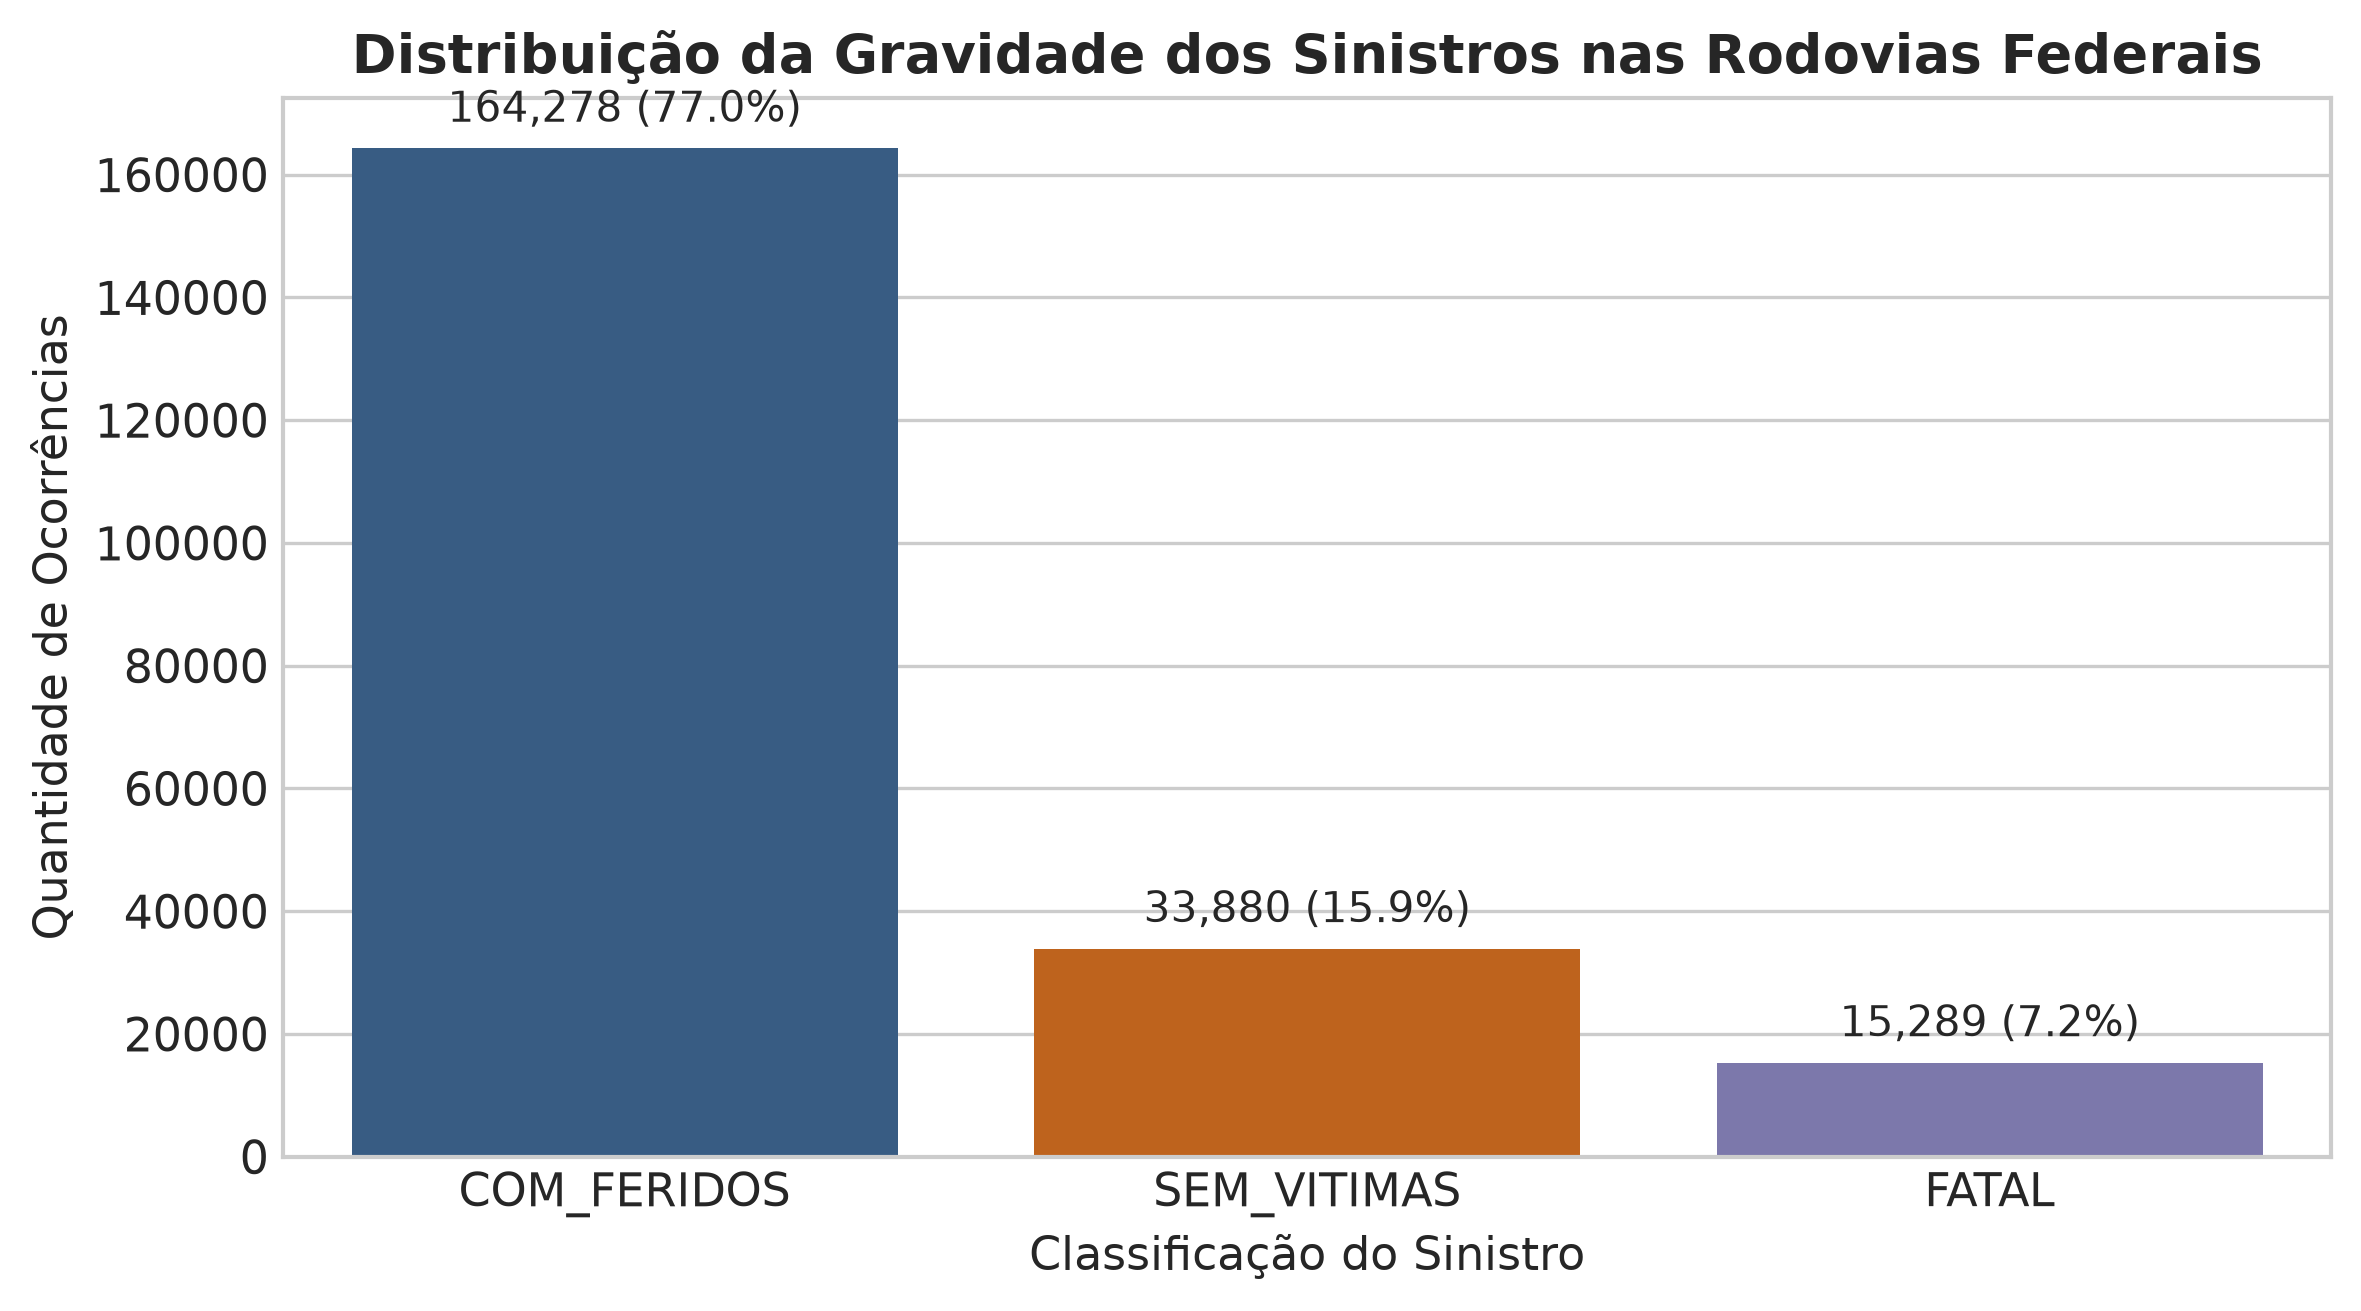

In [2]:
# Tabela agregada da variável alvo categórica
resumo_alvo = df['alvo_severidade'].value_counts().reset_index()
resumo_alvo.columns = ['Severidade', 'Total de Ocorrências']
resumo_alvo['Proporção (%)'] = ((resumo_alvo['Total de Ocorrências'] / len(df)) * 100).round(2)

print("--- Distribuição da Severidade Categórica ---")
print(resumo_alvo)
resumo_alvo.to_csv('../data/outputs/tabela_distribuicao_severidade.csv', index=False, sep=';')

# Gráfico de barras da severidade
plt.figure(figsize=(8, 4.5))
cores = ['#2b5c8f', '#d95f02', '#7570b3']
ax = sns.barplot(data=resumo_alvo, x='Severidade', y='Total de Ocorrências', palette=cores)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura):,} ({altura/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                textcoords='offset points')

plt.title('Distribuição da Gravidade dos Sinistros nas Rodovias Federais')
plt.xlabel('Classificação do Sinistro')
plt.ylabel('Quantidade de Ocorrências')
plt.tight_layout()
plt.savefig('../figures/01_distribuicao_severidade.png')
plt.show()

### 3. Padrões Temporais (Hora do Dia e Dia da Semana)

Identifica horários de pico e dias críticos de acidentalidade

C:\Users\karin\AppData\Local\Temp\ipykernel_25084\3619932169.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dia_semana', order=dias_presentes, palette='Blues_r', ax=axes[1])


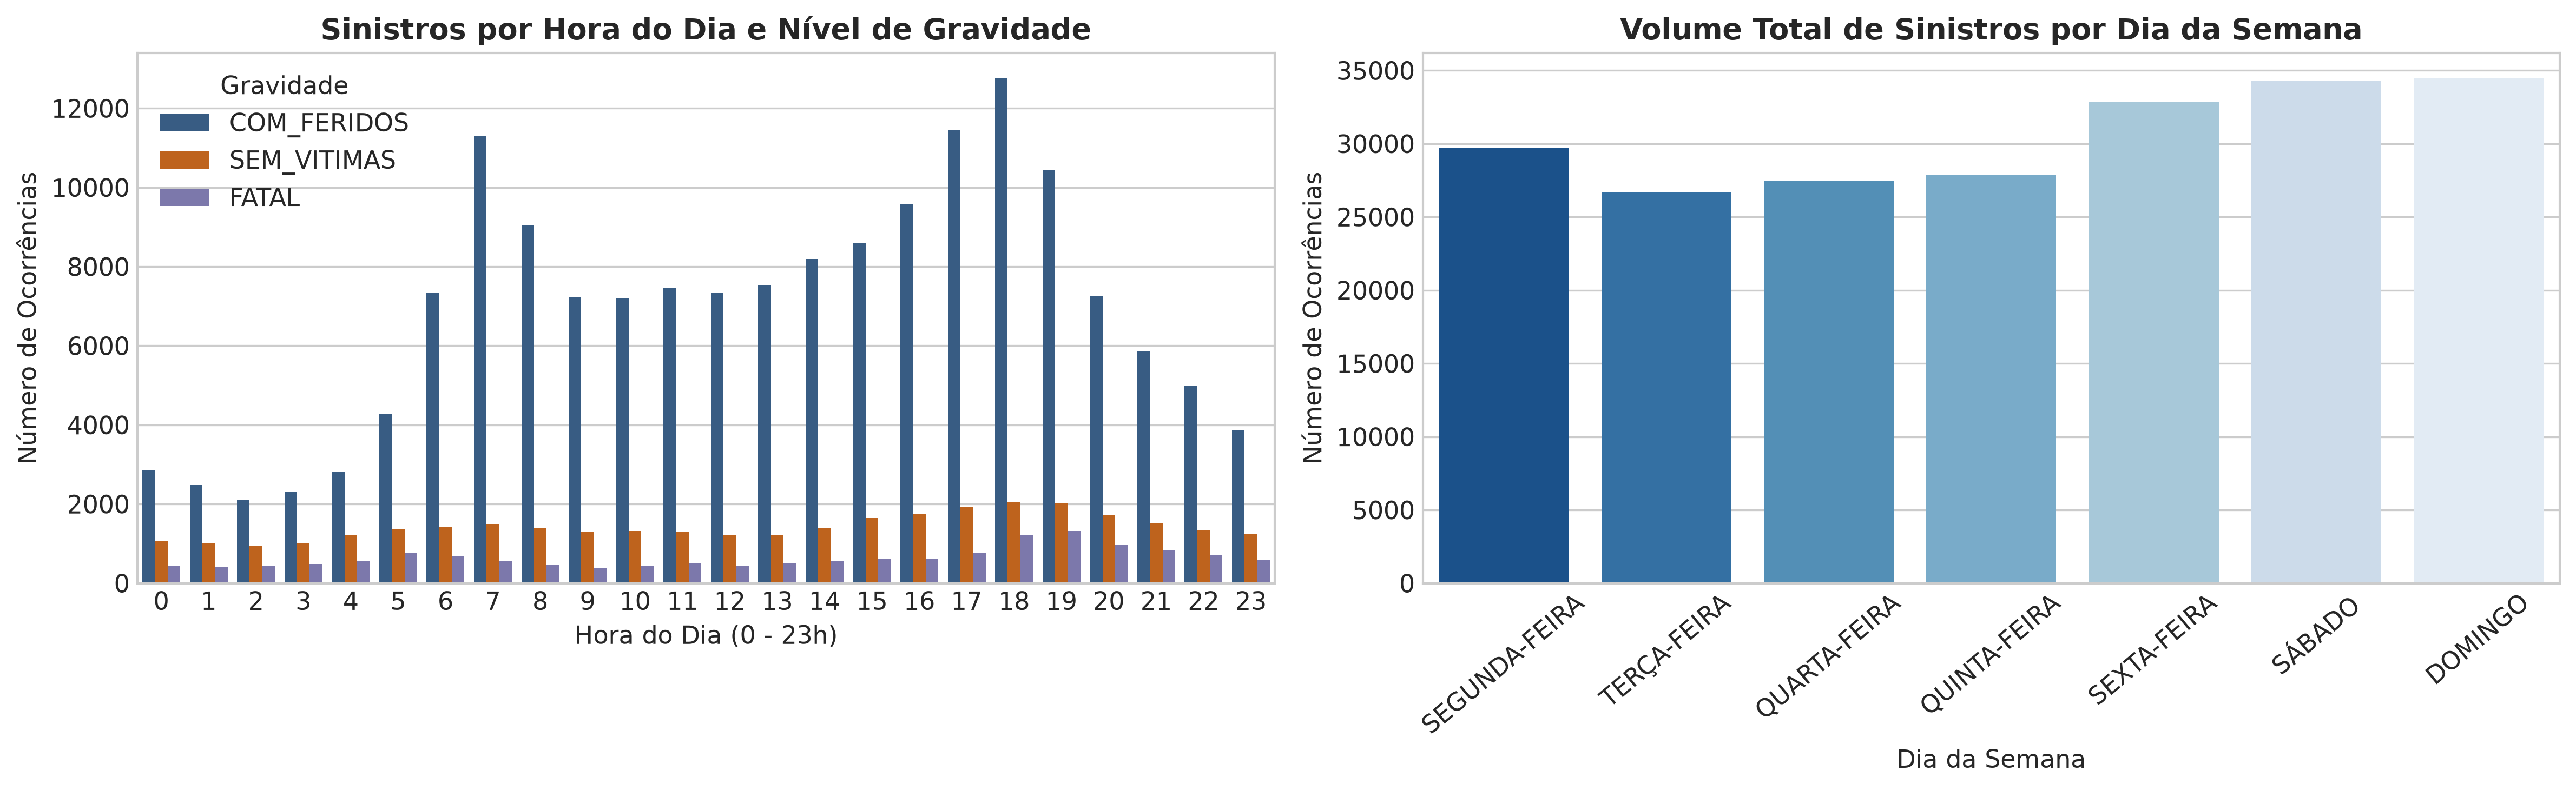

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribuição por Hora do Dia e Severidade
sns.countplot(data=df, x='hora', hue='alvo_severidade', palette=cores, ax=axes[0])
axes[0].set_title('Sinistros por Hora do Dia e Nível de Gravidade')
axes[0].set_xlabel('Hora do Dia (0 - 23h)')
axes[0].set_ylabel('Número de Ocorrências')
axes[0].legend(title='Gravidade')

# 2. Distribuição por Dia da Semana ordenado
ordem_dias = ['SEGUNDA-FEIRA', 'TERÇA-FEIRA', 'QUARTA-FEIRA', 'QUINTA-FEIRA', 'SEXTA-FEIRA', 'SÁBADO', 'DOMINGO']
dias_presentes = [d for d in ordem_dias if d in df['dia_semana'].unique()]

sns.countplot(data=df, x='dia_semana', order=dias_presentes, palette='Blues_r', ax=axes[1])
axes[1].set_title('Volume Total de Sinistros por Dia da Semana')
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('Número de Ocorrências')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('../figures/02_padroes_temporais.png')
plt.show()

### 4. Fatores Ambientais e Viários vs. Severidade

Cruza variáveis que alimentarão o Random Forest (traçado da via, tipo de pista e condições meteorológicas) com a severidade.

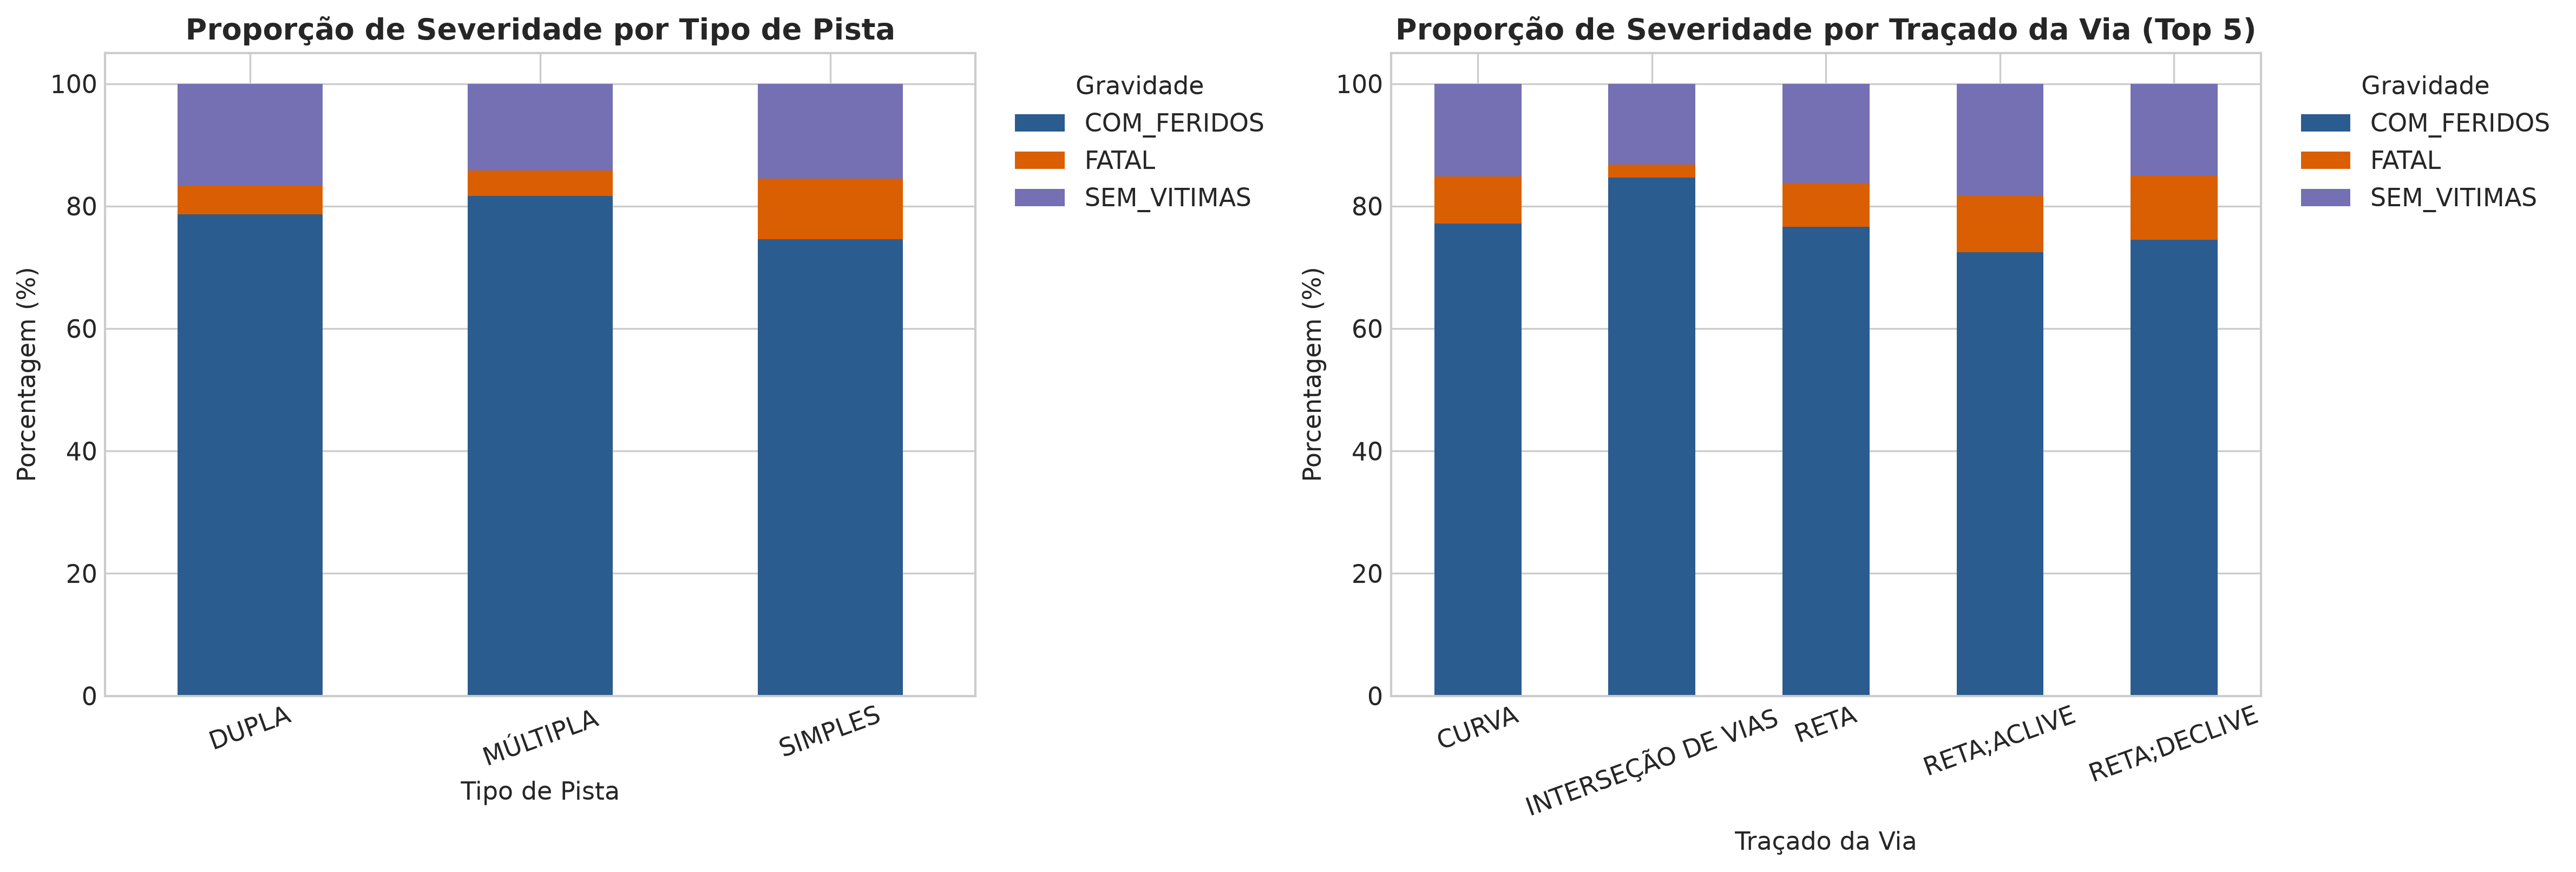

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Severidade por Tipo de Pista (Normalizado em %)
crosstab_pista = pd.crosstab(df['tipo_pista'], df['alvo_severidade'], normalize='index') * 100
crosstab_pista.plot(kind='bar', stacked=True, color=cores, ax=axes[0])
axes[0].set_title('Proporção de Severidade por Tipo de Pista')
axes[0].set_xlabel('Tipo de Pista')
axes[0].set_ylabel('Porcentagem (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

# 2. Severidade por Traçado da Via (Top 5 tipos mais frequentes)
top_tracados = df['tracado_via'].value_counts().nlargest(5).index
df_tracado = df[df['tracado_via'].isin(top_tracados)]
crosstab_tracado = pd.crosstab(df_tracado['tracado_via'], df_tracado['alvo_severidade'], normalize='index') * 100
crosstab_tracado.plot(kind='bar', stacked=True, color=cores, ax=axes[1])
axes[1].set_title('Proporção de Severidade por Traçado da Via (Top 5)')
axes[1].set_xlabel('Traçado da Via')
axes[1].set_ylabel('Porcentagem (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Gravidade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/03_fatores_viarios_severidade.png')
plt.show()

### 5. Distribuição Espacial Básica (Rankings de Rodovias e UFs)

Ranquear os estados e as rodovias federais com maior volume e maior índice médio de severidade.   

C:\Users\karin\AppData\Local\Temp\ipykernel_25084\3975228462.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_brs, x='Total', y='Rodovia', palette='crest', ax=axes[0])
C:\Users\karin\AppData\Local\Temp\ipykernel_25084\3975228462.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uf_sev, x='indice_severidade', y='uf', palette='flare', ax=axes[1])


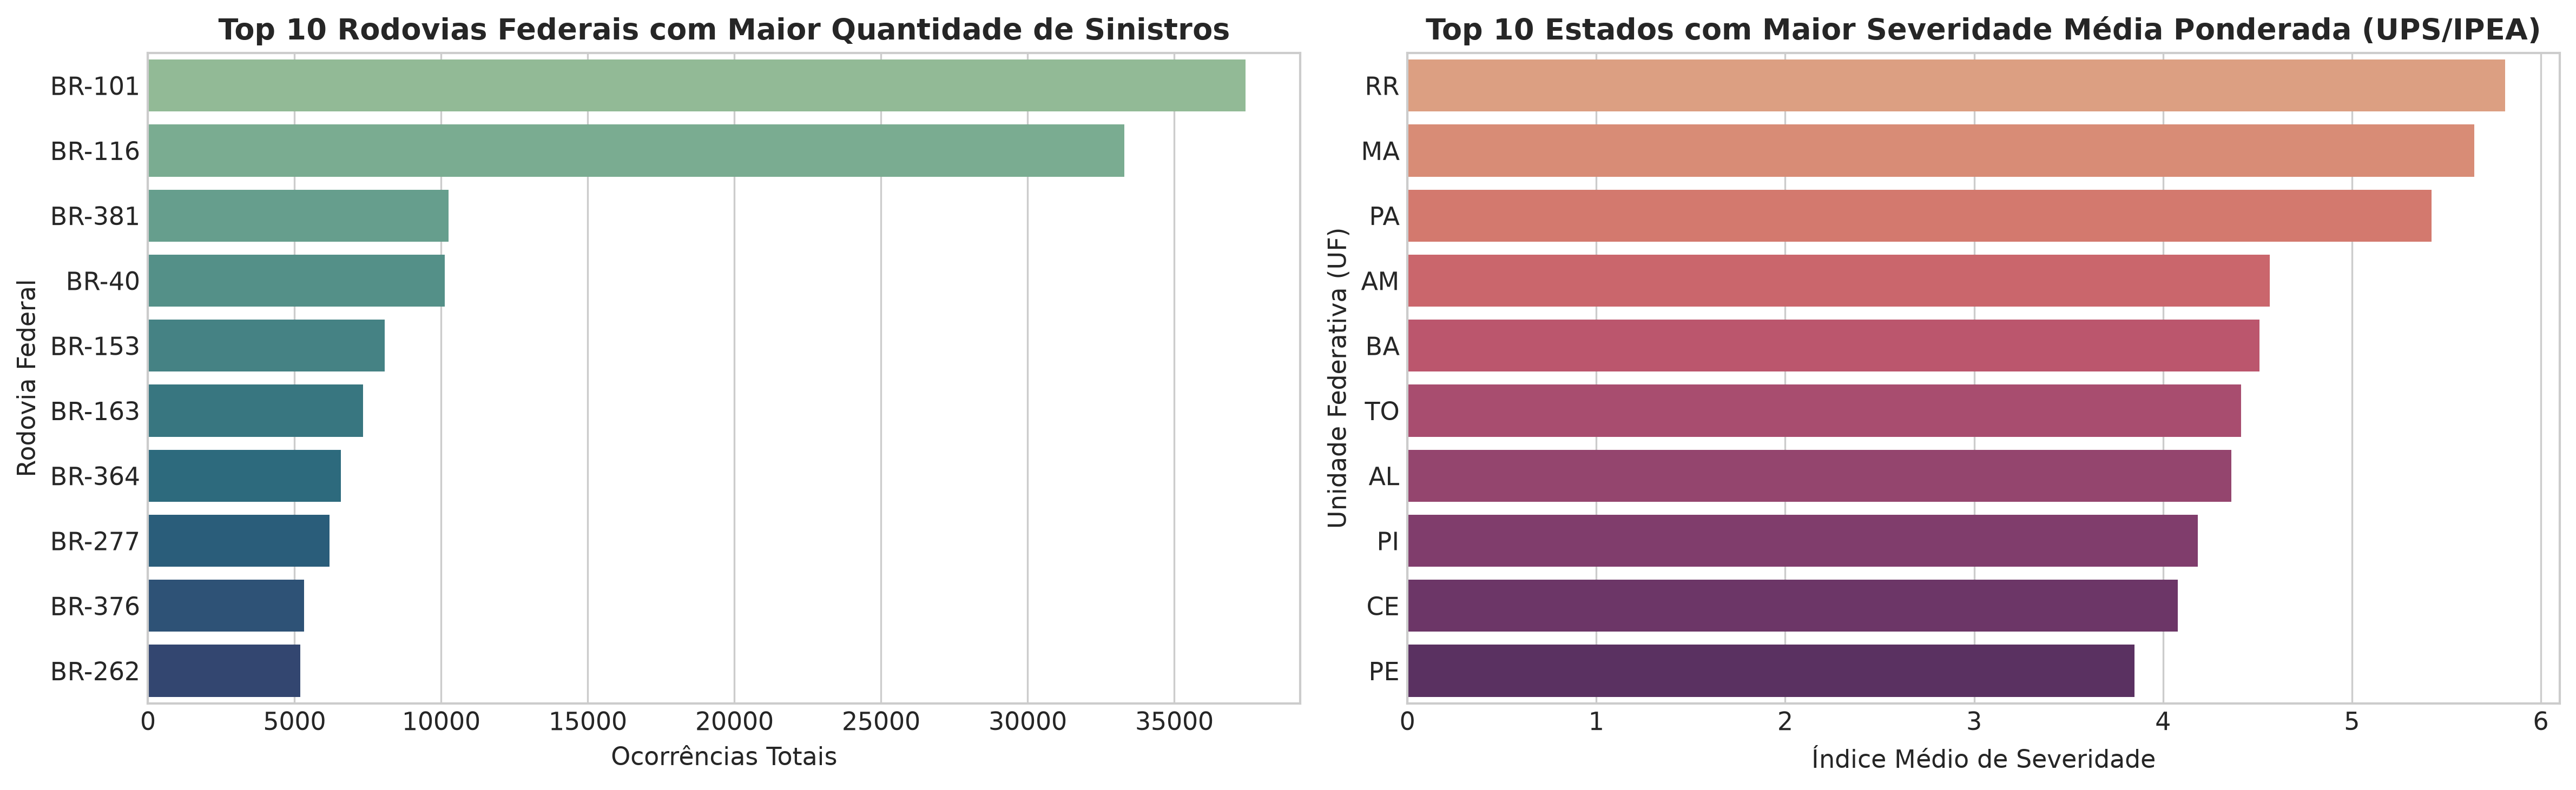

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Top 10 Rodovias (BRs) com mais ocorrências
top_brs = df['br'].value_counts().nlargest(10).reset_index()
top_brs.columns = ['Rodovia', 'Total']
top_brs['Rodovia'] = 'BR-' + top_brs['Rodovia'].astype(str)

sns.barplot(data=top_brs, x='Total', y='Rodovia', palette='crest', ax=axes[0])
axes[0].set_title('Top 10 Rodovias Federais com Maior Quantidade de Sinistros')
axes[0].set_xlabel('Ocorrências Totais')
axes[0].set_ylabel('Rodovia Federal')

# 2. Top 10 Estados (UFs) com maior Índice Médio de Severidade
uf_sev = df.groupby('uf')['indice_severidade'].mean().nlargest(10).reset_index()
sns.barplot(data=uf_sev, x='indice_severidade', y='uf', palette='flare', ax=axes[1])
axes[1].set_title('Top 10 Estados com Maior Severidade Média Ponderada (UPS/IPEA)')
axes[1].set_xlabel('Índice Médio de Severidade')
axes[1].set_ylabel('Unidade Federativa (UF)')

plt.tight_layout()
plt.savefig('../figures/04_distribuicao_espacial_rankings.png')
plt.show()

### 6. Mapa Espacial Preliminar com Scatter Plot Geoespacial

Visualização da distribuição dos pontos georreferenciados no território nacional com base nas colunas latitude e longitude tratadas no pré-processamento.   

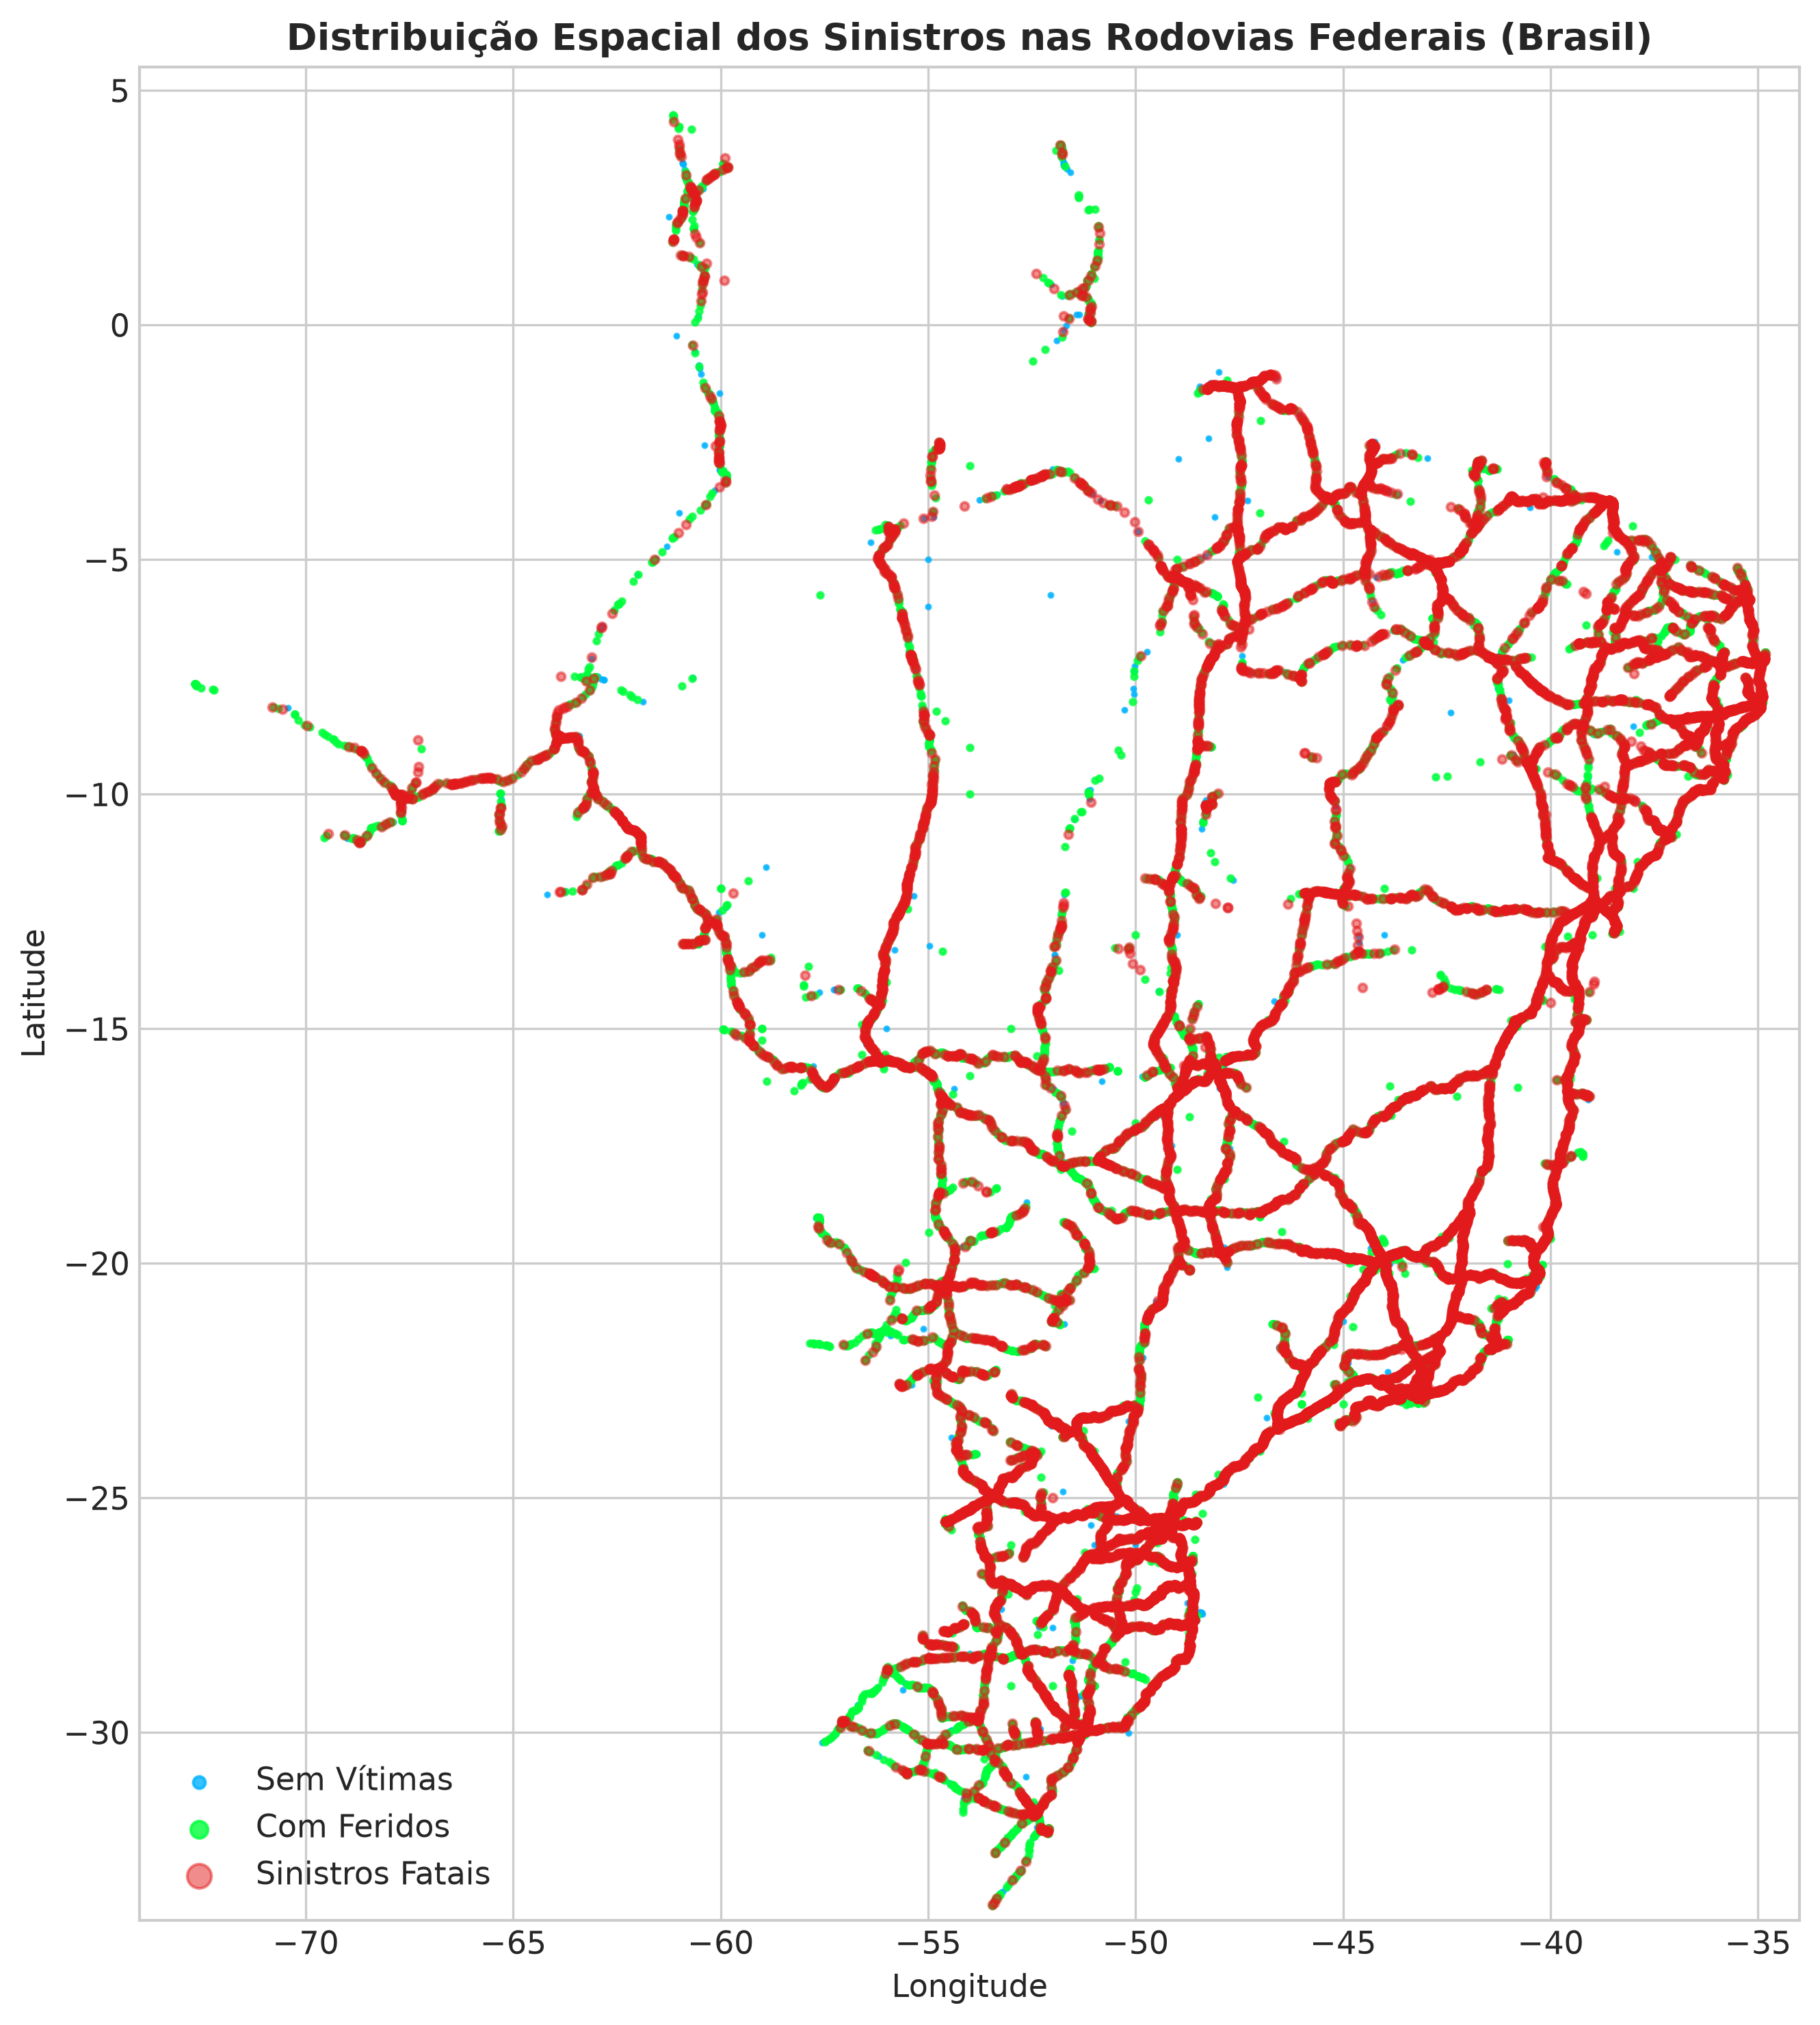

In [10]:
plt.figure(figsize=(9, 10))

# Plotagem dos pontos sem vítimas (em cinza/transparente de fundo)
sem_vit = df[df['alvo_severidade'] == 'SEM_VITIMAS']
plt.scatter(sem_vit['longitude'], sem_vit['latitude'], 
            c="#00b3ff", alpha=0.8, s=2, label='Sem Vítimas')

# Plotagem dos pontos com feridos
feridos = df[df['alvo_severidade'] == 'COM_FERIDOS']
plt.scatter(feridos['longitude'], feridos['latitude'], 
            c="#00ff3c", alpha=0.8, s=4, label='Com Feridos')

# Plotagem dos sinistros fatais (em vermelho para destaque visual de eixos críticos)
fatais = df[df['alvo_severidade'] == 'FATAL']
plt.scatter(fatais['longitude'], fatais['latitude'], 
            c='#e41a1c', alpha=0.5, s=8, label='Sinistros Fatais')

plt.title('Distribuição Espacial dos Sinistros nas Rodovias Federais (Brasil)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='lower left', markerscale=3)
plt.xlim(-74, -34)
plt.ylim(-34, 5.5)

plt.tight_layout()
plt.savefig('../figures/05_mapa_dispersao_espacial.png')
plt.show()